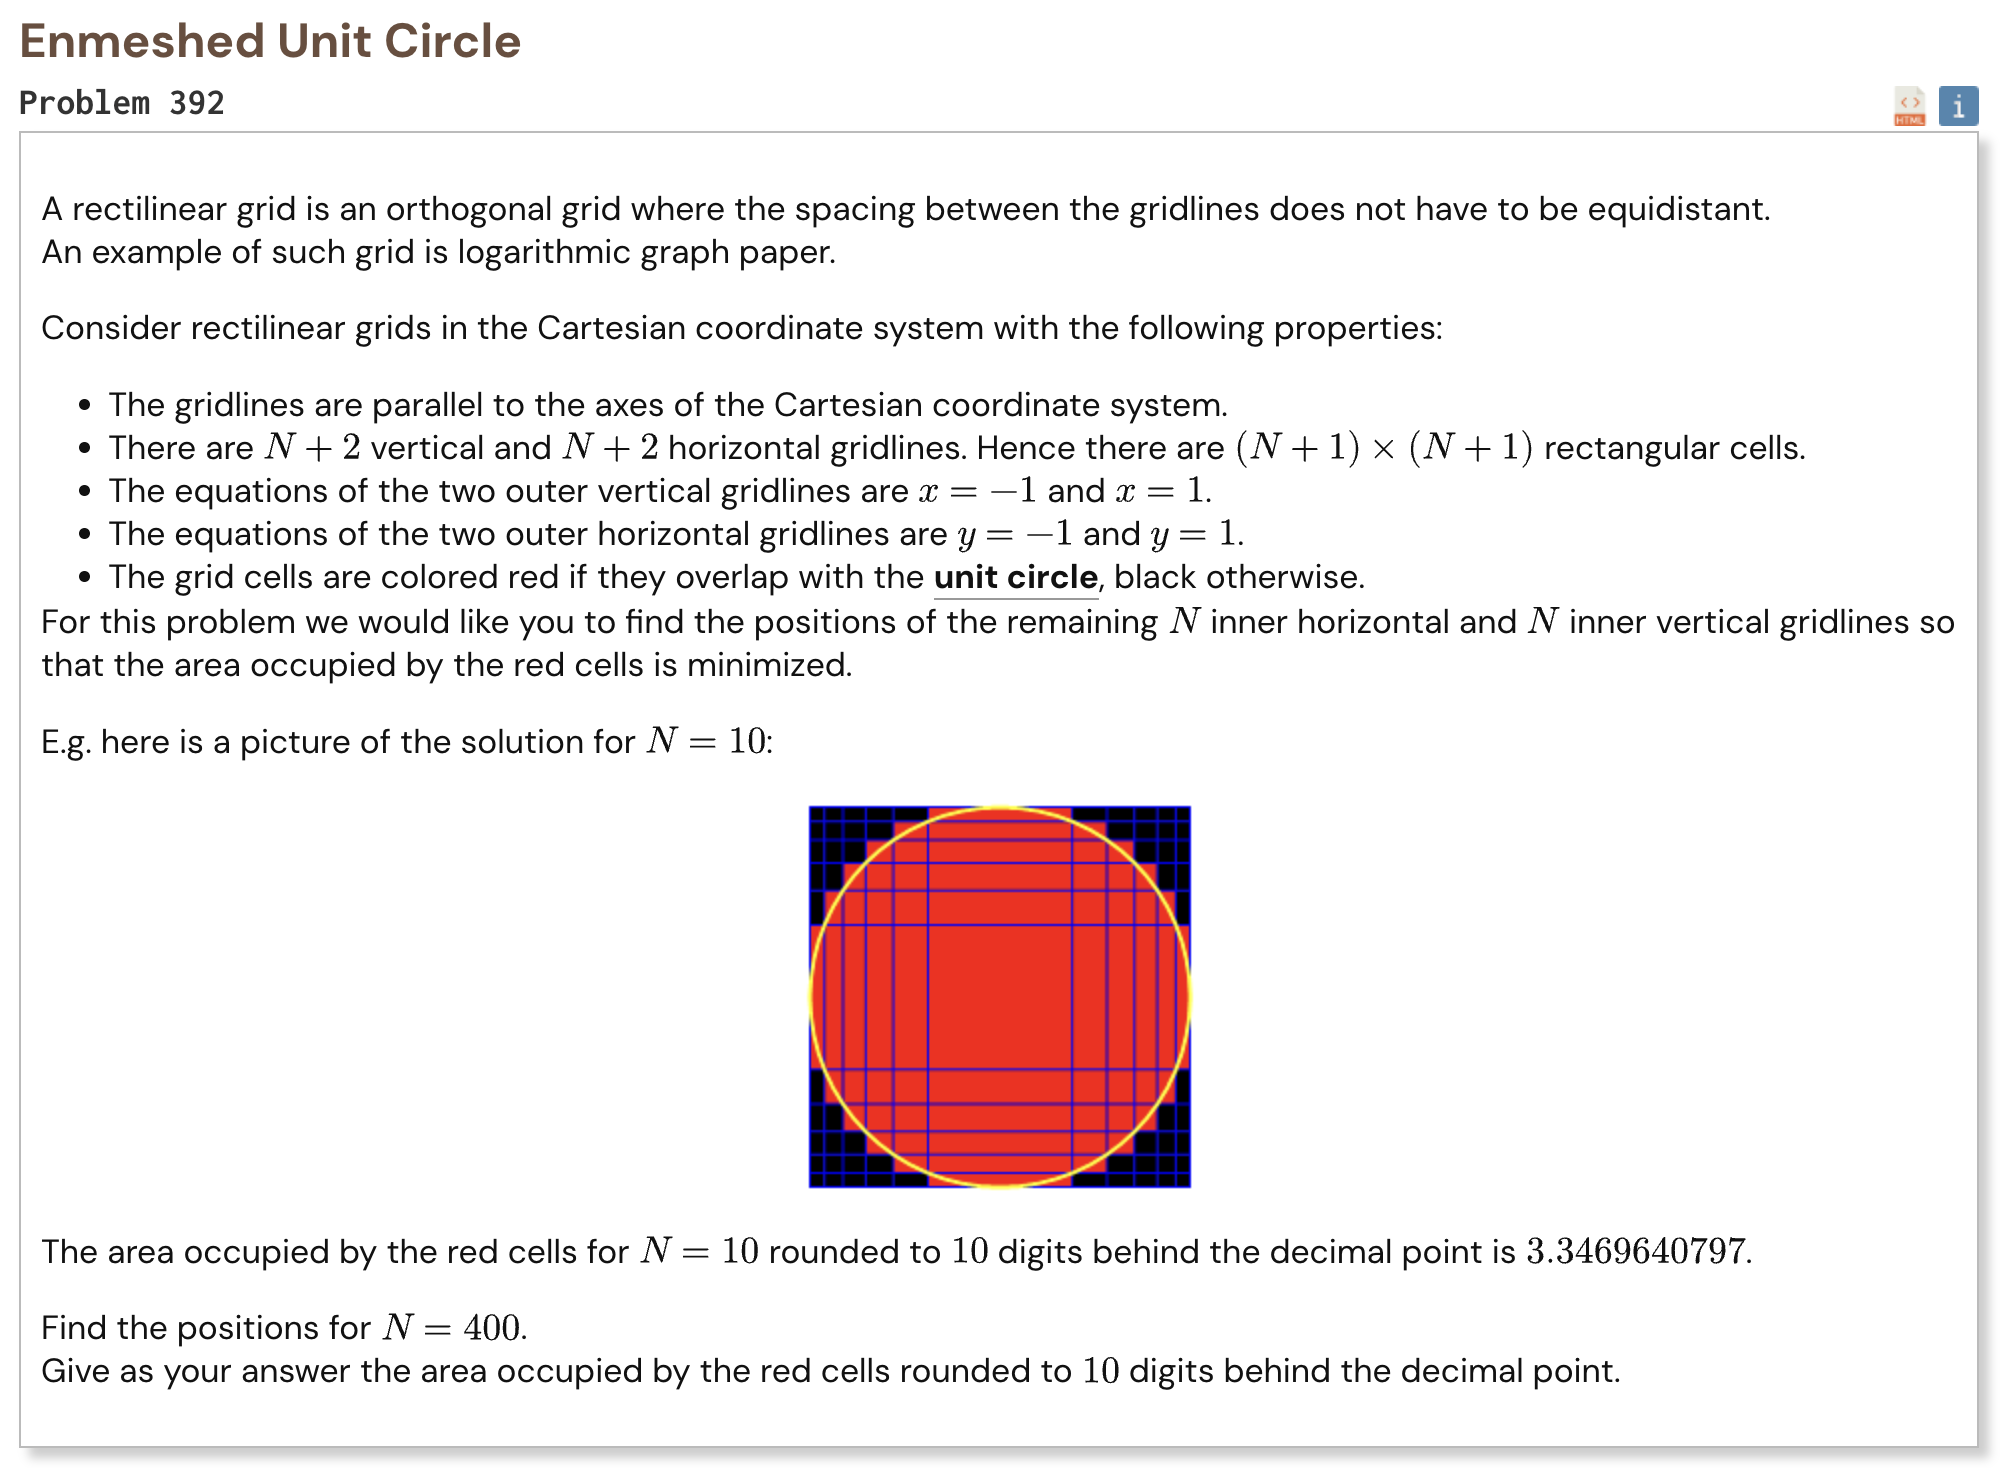

## Initial approach

-   use symmetry to solve only the first quadrant and multiply its area by four
-   split the quadrant into 201 intervals because N is 400
-   the red cells form a staircase that stays outside the quarter circle
-   at the best grid each inner staircase corner touches the circle
-   write the quarter circle as y equals the square root of one minus x squared
-   minimize the staircase area by setting the derivative for every inner point to zero
-   this gives a recurrence that generates all grid positions from the first position

In [1]:
import math


def circle_height(x):
    return math.sqrt(max(0.0, 1.0 - x * x))


def final_position(intervals, first_position):
    current = first_position
    previous_height = 1.0

    for _ in range(1, intervals):
        if current >= 1.0:
            return current

        current_height = circle_height(current)

        next_position = (
            current
            + (previous_height - current_height)
            * current_height
            / current
        )

        current = next_position
        previous_height = current_height

    return current


def solve(n):
    intervals = n // 2 + 1

    low = 1e-12
    high = 0.9

    while final_position(intervals, low) >= 1.0:
        low *= 0.5

    while final_position(intervals, high) <= 1.0:
        high = (high + 1.0) / 2.0

    for _ in range(200):
        middle = (low + high) / 2.0

        if final_position(intervals, middle) > 1.0:
            high = middle
        else:
            low = middle

    first_position = (low + high) / 2.0
    positions = [0.0, first_position]
    previous_height = 1.0

    for index in range(1, intervals):
        current = positions[index]
        current_height = circle_height(current)

        next_position = (
            current
            + (previous_height - current_height)
            * current_height
            / current
        )

        positions.append(next_position)
        previous_height = current_height

    quadrant_area = 0.0

    for index in range(intervals):
        width = positions[index + 1] - positions[index]
        height = circle_height(positions[index])
        quadrant_area += width * height

    return 4.0 * quadrant_area

In [2]:
%%time
assert f"{solve(10):.10f}" == "3.3469640797"
result = solve(400)
print("Result:", f"{result:.10f}")

Result: 3.1486734435
CPU times: user 11.7 ms, sys: 973 μs, total: 12.7 ms
Wall time: 12.2 ms
